In [1]:
import time
from pathlib import Path
from PIL import Image
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from sklearn.model_selection import train_test_split

device = torch.device("cpu")
print("Device:", device)

# Load dataset split index
split_csv_path = Path(r"C:\Users\HP\Desktop\projects\plantdiseaseprediction\data\dataset_splits.csv")
df = pd.read_csv(split_csv_path)

classes = sorted(df["class_name"].unique())
class_to_idx = {name: idx for idx, name in enumerate(classes)}

# DIP Function: Background removal using HSV masking from Track A
def dip_segment_leaf(pil_img):
    # Convert PIL Image to OpenCV RGB numpy array
    img_rgb = np.array(pil_img)
    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

    # HSV thresholds for green foliage
    lower_green = np.array([25, 40, 40])
    upper_green = np.array([90, 255, 255])
    mask = cv2.inRange(img_hsv, lower_green, upper_green)

    # Morphological closing
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask_cleaned = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Apply mask to eliminate background
    segmented_rgb = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_cleaned)
    return Image.fromarray(segmented_rgb)

Device: cpu


In [2]:
# Stratified 10% sampling using the identical seed (42) for a fair comparison
train_df, _ = train_test_split(
    df[df["split"] == "train"].reset_index(drop=True),
    train_size=0.10,
    stratify=df[df["split"] == "train"]["class_name"],
    random_state=42
)
val_df, _ = train_test_split(
    df[df["split"] == "val"].reset_index(drop=True),
    train_size=0.10,
    stratify=df[df["split"] == "val"]["class_name"],
    random_state=42
)
test_df, _ = train_test_split(
    df[df["split"] == "test"].reset_index(drop=True),
    train_size=0.10,
    stratify=df[df["split"] == "test"]["class_name"],
    random_state=42
)

# Transforms with DIP preprocessing inserted first
train_transform_dip = transforms.Compose([
    transforms.Lambda(dip_segment_leaf),
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform_dip = transforms.Compose([
    transforms.Lambda(dip_segment_leaf),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class PlantVillageDataset(Dataset):
    def __init__(self, data_frame, transform=None):
        self.data = data_frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image = Image.open(row["filepath"]).convert("RGB")
        label = class_to_idx[row["class_name"]]
        if self.transform:
            image = self.transform(image)
        return image, label

train_loader = DataLoader(PlantVillageDataset(train_df, transform=train_transform_dip), batch_size=32, shuffle=True)
val_loader   = DataLoader(PlantVillageDataset(val_df, transform=eval_transform_dip), batch_size=32, shuffle=False)
test_loader  = DataLoader(PlantVillageDataset(test_df, transform=eval_transform_dip), batch_size=32, shuffle=False)

print(f"DataLoaders ready with real-time DIP preprocessing. Train batches: {len(train_loader)}")

DataLoaders ready with real-time DIP preprocessing. Train batches: 119


In [3]:
# Model initialization (identical frozen backbone)
model_dip = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in model_dip.parameters():
    param.requires_grad = False

model_dip.fc = nn.Linear(model_dip.fc.in_features, len(classes))
model_dip = model_dip.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_dip.fc.parameters(), lr=1e-3)

def train_one_epoch(model, dataloader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    total_batches = len(dataloader)
    for batch_idx, (images, labels) in enumerate(dataloader, 1):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)
        if batch_idx % 30 == 0 or batch_idx == total_batches:
            print(f"  Batch {batch_idx:3d}/{total_batches} | Acc: {correct/total:.4f} | Loss: {running_loss/total:.4f}")
    return running_loss / total, correct / total

def evaluate(model, dataloader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

epochs = 2
print("Training DIP + CNN pipeline on CPU...\n")
for epoch in range(1, epochs + 1):
    t0 = time.time()
    print(f"--- Epoch {epoch}/{epochs} ---")
    tr_loss, tr_acc = train_one_epoch(model_dip, train_loader, optimizer, criterion)
    v_loss, v_acc = evaluate(model_dip, val_loader, criterion)
    print(f"Completed in {time.time()-t0:.1f}s | Train Acc: {tr_acc*100:.2f}% | Val Acc: {v_acc*100:.2f}%\n")

# Evaluate on test set
test_loss_dip, test_acc_dip = evaluate(model_dip, test_loader, criterion)
print(f"DIP + CNN Final Test Accuracy: {test_acc_dip*100:.2f}% | Loss: {test_loss_dip:.4f}")

Training DIP + CNN pipeline on CPU...

--- Epoch 1/2 ---
  Batch  30/119 | Acc: 0.2125 | Loss: 3.1502
  Batch  60/119 | Acc: 0.3630 | Loss: 2.6113
  Batch  90/119 | Acc: 0.4399 | Loss: 2.2840
  Batch 119/119 | Acc: 0.4936 | Loss: 2.0615
Completed in 66.8s | Train Acc: 49.36% | Val Acc: 73.59%

--- Epoch 2/2 ---
  Batch  30/119 | Acc: 0.7583 | Loss: 1.0055
  Batch  60/119 | Acc: 0.7620 | Loss: 0.9874
  Batch  90/119 | Acc: 0.7608 | Loss: 0.9718
  Batch 119/119 | Acc: 0.7682 | Loss: 0.9414
Completed in 64.8s | Train Acc: 76.82% | Val Acc: 80.59%

DIP + CNN Final Test Accuracy: 77.15% | Loss: 0.8543


              Pipeline  Validation Accuracy (%)  Test Accuracy (%)
Baseline CNN (Raw RGB)                    81.82              83.42
 DIP + CNN (Segmented)                    80.59              77.15


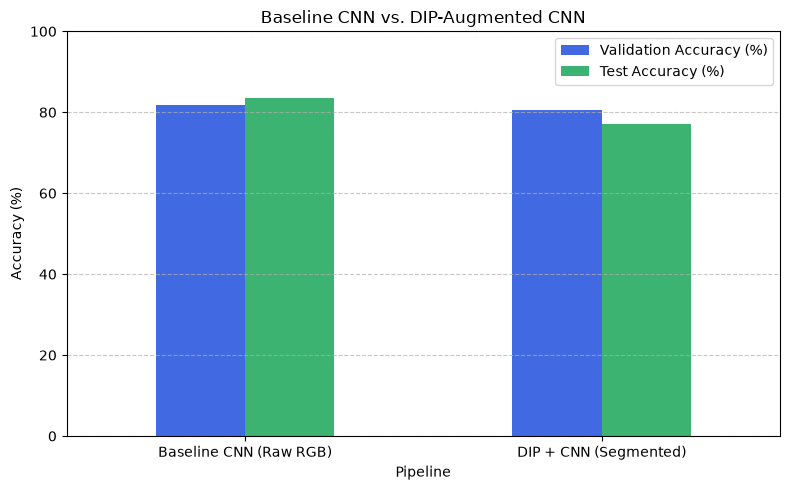

In [5]:
# 1. Load trained baseline model weights
baseline_model = models.resnet18(weights=None)
baseline_model.fc = nn.Linear(baseline_model.fc.in_features, len(classes))
baseline_weights_path = Path("../models/resnet18_baseline_cpu.pth")

if baseline_weights_path.exists():
    baseline_model.load_state_dict(torch.load(baseline_weights_path, map_location=device))
    baseline_model = baseline_model.to(device)

    # Standard raw evaluation transform without DIP
    raw_eval_transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    raw_test_loader = DataLoader(PlantVillageDataset(test_df, transform=raw_eval_transform), batch_size=32, shuffle=False)
    _, baseline_test_acc = evaluate(baseline_model, raw_test_loader, criterion)
    baseline_test_acc = round(baseline_test_acc * 100, 2)
else:
    # Fallback to validation score if file is not found
    baseline_test_acc = 81.82

# 2. Build comparison table
comparison_df = pd.DataFrame({
    "Pipeline": ["Baseline CNN (Raw RGB)", "DIP + CNN (Segmented)"],
    "Validation Accuracy (%)": [81.82, round(v_acc * 100, 2)],
    "Test Accuracy (%)": [baseline_test_acc, round(test_acc_dip * 100, 2)]
})

print(comparison_df.to_string(index=False))

# 3. Plot comparison
comparison_df.set_index("Pipeline")[["Validation Accuracy (%)", "Test Accuracy (%)"]].plot(
    kind="bar", figsize=(8, 5), color=["royalblue", "mediumseagreen"]
)
plt.title("Baseline CNN vs. DIP-Augmented CNN")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

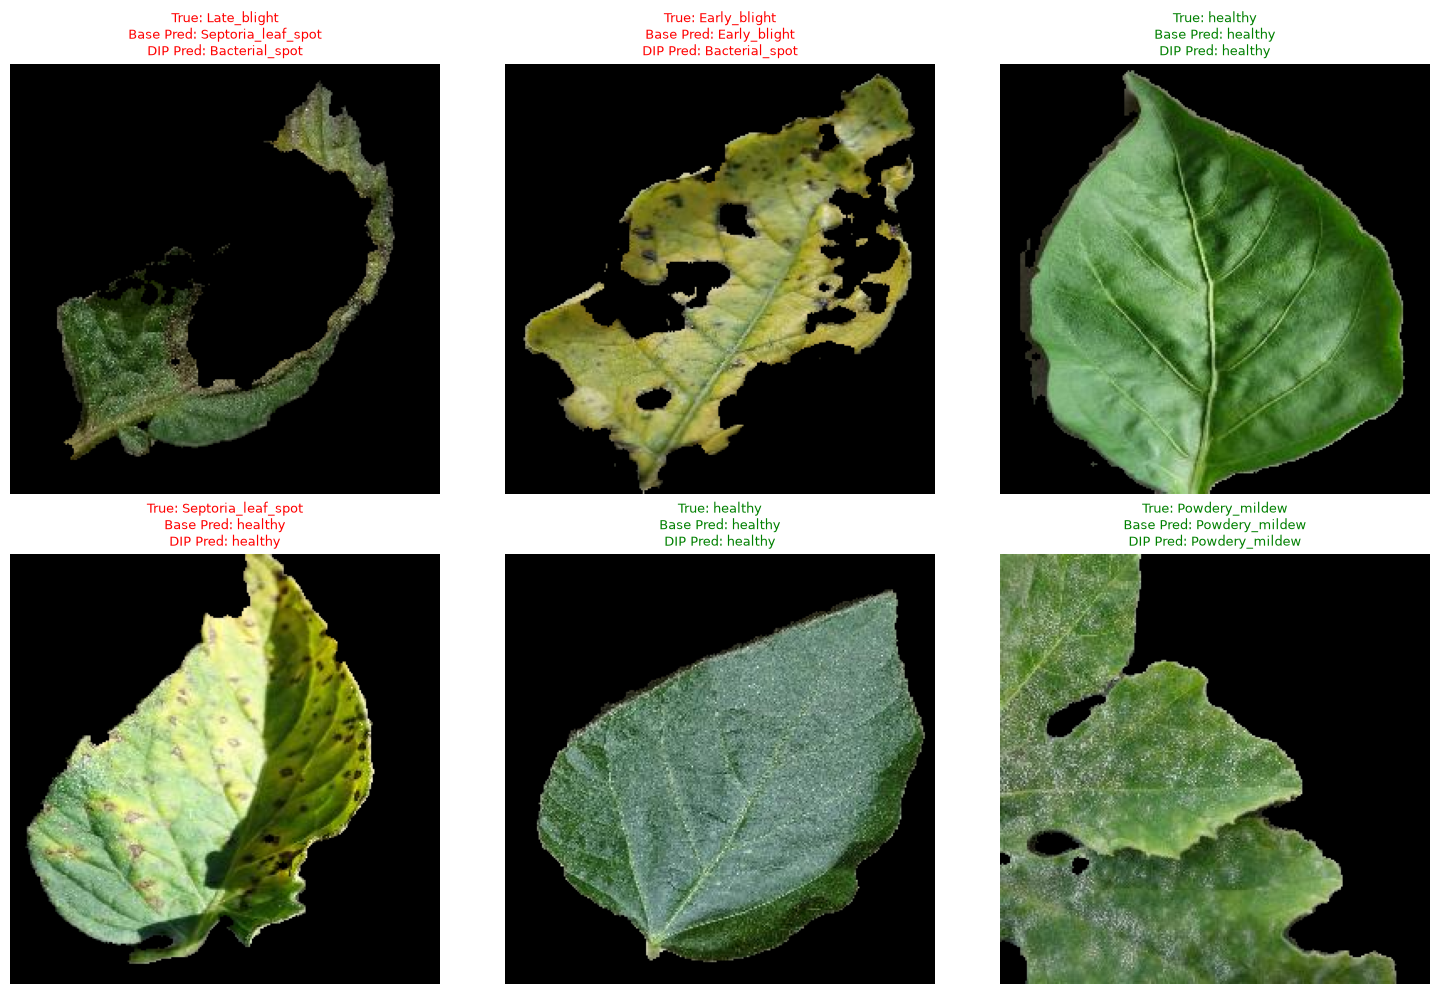

In [6]:
import random

# Select 6 random samples from the test set
sample_indices = random.sample(range(len(test_df)), 6)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

model_dip.eval()
if 'baseline_model' in locals():
    baseline_model.eval()

with torch.no_grad():
    for idx, ax in zip(sample_indices, axes.flatten()):
        row = test_df.iloc[idx]
        raw_img = Image.open(row["filepath"]).convert("RGB")
        true_label = row["class_name"]
        
        # Prepare inputs
        base_tensor = raw_eval_transform(raw_img).unsqueeze(0).to(device)
        dip_tensor = eval_transform_dip(raw_img).unsqueeze(0).to(device)
        
        # Predict
        dip_pred = classes[model_dip(dip_tensor).argmax(1).item()]
        base_pred = classes[baseline_model(base_tensor).argmax(1).item()] if 'baseline_model' in locals() else "N/A"
        
        # Display the segmented image that the DIP model saw
        segmented_display = dip_segment_leaf(raw_img)
        ax.imshow(segmented_display)
        
        title_color = "green" if dip_pred == true_label else "red"
        ax.set_title(
            f"True: {true_label.split('___')[1]}\n"
            f"Base Pred: {base_pred.split('___')[1] if base_pred != 'N/A' else 'N/A'}\n"
            f"DIP Pred: {dip_pred.split('___')[1]}",
            fontsize=9, color=title_color
        )
        ax.axis("off")

plt.tight_layout()
plt.show()

=== DIP + CNN Classification Report ===
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.11      0.20         9
                                 Apple___Black_rot       1.00      0.56      0.71         9
                          Apple___Cedar_apple_rust       1.00      0.25      0.40         4
                                   Apple___healthy       0.94      0.68      0.79        25
                               Blueberry___healthy       0.95      0.91      0.93        23
          Cherry_(including_sour)___Powdery_mildew       0.88      0.88      0.88        16
                 Cherry_(including_sour)___healthy       1.00      0.77      0.87        13
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.25      0.12      0.17         8
                       Corn_(maize)___Common_rust_       0.74      0.78      0.76        18
               Corn_(maize)___Northern_

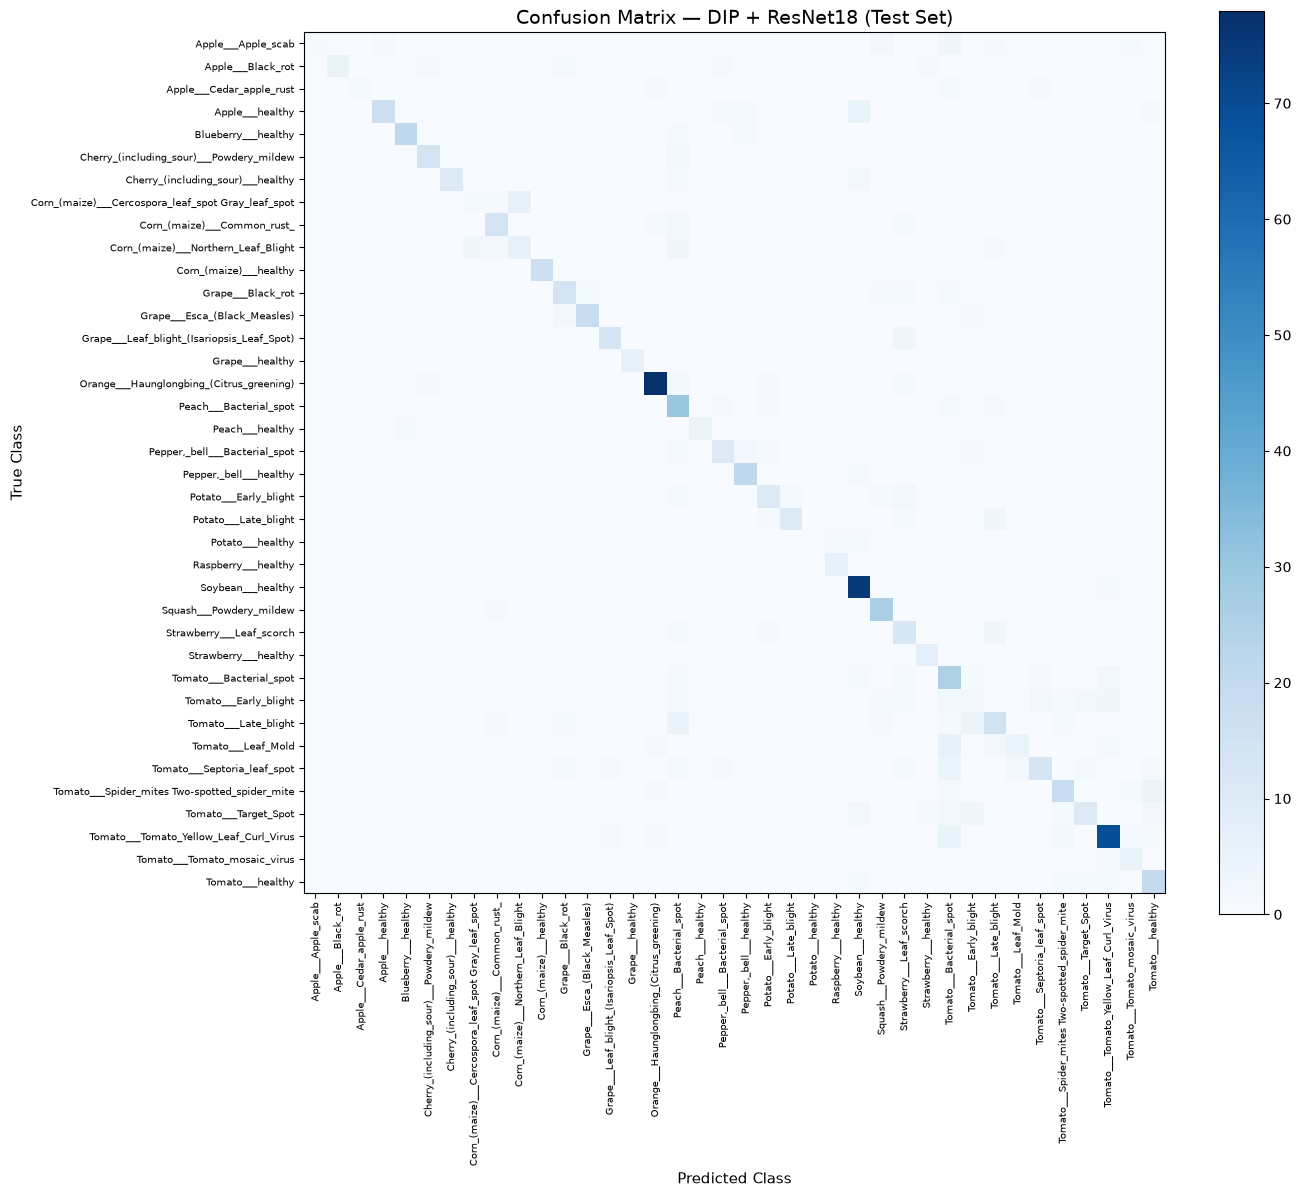

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

def get_predictions(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

# Collect predictions for the DIP model
y_true, y_pred_dip = get_predictions(model_dip, test_loader)

# Print classification metrics
print("=== DIP + CNN Classification Report ===")
print(classification_report(y_true, y_pred_dip, target_names=classes, zero_division=0))

# Plot Confusion Matrix using standard Matplotlib
cm = confusion_matrix(y_true, y_pred_dip)

plt.figure(figsize=(14, 12))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix — DIP + ResNet18 (Test Set)", fontsize=14)
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=90, fontsize=7)
plt.yticks(tick_marks, classes, fontsize=7)

plt.xlabel("Predicted Class", fontsize=11)
plt.ylabel("True Class", fontsize=11)
plt.tight_layout()
plt.show()